# House Price Prediction using Machine Learning

This notebook analyzes a real estate dataset and builds multiple machine learning models to predict house prices.

In [1]:
# Import pandas library for data handling
import pandas as pd

# Load the dataset from the CSV file into a DataFrame
data = pd.read_csv("feature_engineered_dataset.csv")

# Display the first 5 rows of the dataset
# This helps us understand the structure of the data
data.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


In [2]:
# Display information about the dataset
# This shows column names, data types, and number of non-null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4566 entries, 0 to 4565
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   xrCompositeLandUseID     4566 non-null   int64  
 1   xrBuildingTypeID         4566 non-null   float64
 2   LocationStartNumber      4566 non-null   int64  
 3   StreetNameAndWay         4566 non-null   object 
 4   xrPrimaryNeighborhoodID  4566 non-null   int64  
 5   LandSF                   4566 non-null   float64
 6   TotalFinishedArea        4566 non-null   float64
 7   LivingUnits              4566 non-null   float64
 8   OwnerLastName            4566 non-null   object 
 9   SaleDate                 4566 non-null   object 
 10  SalePrice                4566 non-null   float64
 11  TotalAppraisedValue      4566 non-null   int64  
 12  xrSalesValidityID        4566 non-null   int64  
 13  xrDeedID                 4566 non-null   int64  
 14  AssrLandUse             

In [3]:
# Select only numerical columns from the dataset
# This removes text columns like StreetNameAndWay and OwnerLastName
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Define the target variable (what we want to predict)
y = numeric_data['LogSalePrice']

# Define the feature variables (input variables for the model)
# Drop the target column from the features
X = numeric_data.drop(columns=['LogSalePrice'])

# Display the shape of feature matrix and target vector
# This helps confirm how many features and samples we have
X.shape, y.shape

((4566, 16), (4566,))

In [4]:
# Import train_test_split function from sklearn
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% data for training the model
# 20% data for testing the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the shape of the split datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3652, 16), (914, 16), (3652,), (914,))

In [6]:
# Import numpy to handle infinity values
import numpy as np

# Replace infinity values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill NaN values with column mean
X = X.fillna(X.mean())

# Check again if any infinite values exist
np.isinf(X).sum().sum()

np.int64(0)

In [7]:
# Split the cleaned dataset again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((3652, 16), (914, 16))

In [8]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Create the model
# random_state ensures the results are reproducible
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model using the training dataset
dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [9]:
# Use the trained Decision Tree model to predict house prices
# Predictions are made on the test dataset (unseen data)
y_pred = dt_model.predict(X_test)

# Display the first 10 predicted values
y_pred[:10]

array([12.34583894, 12.16525586, 12.20607765, 10.59665973, 12.79386209,
       12.75708294, 16.14280241, 12.0435596 , 12.40901757, 11.05881093])

In [10]:
# Use the trained Decision Tree model to predict house prices
# Predictions are made on the test dataset (unseen data)
y_pred = dt_model.predict(X_test)

# Display the first 10 predicted values
y_pred[:10]

array([12.34583894, 12.16525586, 12.20607765, 10.59665973, 12.79386209,
       12.75708294, 16.14280241, 12.0435596 , 12.40901757, 11.05881093])

In [11]:
# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = mse ** 0.5

# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Print results
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.0001326924461061859
RMSE: 0.011519220724779343
R2 Score: 0.999963383055451


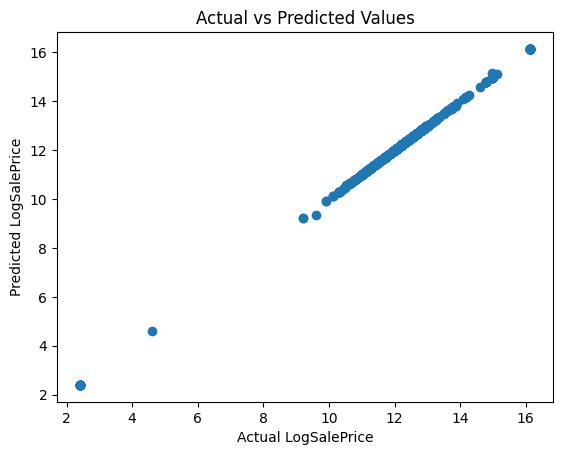

In [12]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred)

# Axis labels
plt.xlabel("Actual LogSalePrice")
plt.ylabel("Predicted LogSalePrice")

# Plot title
plt.title("Actual vs Predicted Values")

# Show plot
plt.show()

## Conclusion

In this analysis, a Decision Tree Regression model was used to predict house prices based on various property features.

The dataset was first explored and cleaned to ensure there were no infinite or missing values. The data was then split into training and testing sets to evaluate the model on unseen data.

The Decision Tree model was trained on the training dataset and used to predict house prices for the test dataset. The evaluation metrics showed very strong performance with a very low RMSE and an R² score close to 1.

The visualization of Actual vs Predicted values also confirmed that the predictions closely match the actual values, indicating that the model successfully captured the relationships between the property features and the sale price.

Overall, the Decision Tree model performed very well for this dataset.

In [13]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [14]:
# Predict using Random Forest model
rf_pred = rf_model.predict(X_test)

# Show first 10 predictions
rf_pred[:10]

array([12.34583894, 12.16525709, 12.20607765, 10.59676957, 12.79372223,
       12.75511696, 16.14280241, 12.0435596 , 12.40901757, 11.06272913])

In [15]:
# Evaluate Random Forest model
from sklearn.metrics import mean_squared_error, r2_score

# Calculate errors
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

# Print results
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MSE: 0.00031109729880800284
Random Forest RMSE: 0.017637950527428146
Random Forest R2 Score: 0.9999141516124385


In [16]:
# Import Gradient Boosting model
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [17]:
# Predict using Gradient Boosting model
gb_pred = gb_model.predict(X_test)

# Show first 10 predictions
gb_pred[:10]

array([12.3431037 , 12.15566713, 12.22095217, 10.60007132, 12.78486625,
       12.75883569, 16.14094008, 12.02574651, 12.38421217, 11.05225708])

In [18]:
# Evaluate Gradient Boosting model

gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = gb_mse ** 0.5
gb_r2 = r2_score(y_test, gb_pred)

# Print results
print("Gradient Boosting MSE:", gb_mse)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R2 Score:", gb_r2)

Gradient Boosting MSE: 0.00022637966600909786
Gradient Boosting RMSE: 0.01504591858309415
Gradient Boosting R2 Score: 0.99993752973948


In [19]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 3.1 MB/s  0:00:003.1 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Import XGBoost model
from xgboost import XGBRegressor

# Create XGBoost model
xgb_model = XGBRegressor(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [21]:
# Predict using XGBoost model
xgb_pred = xgb_model.predict(X_test)

# Show first 10 predictions
xgb_pred[:10]


array([12.3468485, 12.157475 , 12.210771 , 10.596913 , 12.792887 ,
       12.744405 , 16.14267  , 12.042128 , 12.411913 , 11.091984 ],
      dtype=float32)

In [22]:
# Evaluate XGBoost model

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = xgb_mse ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

# Print results
print("XGBoost MSE:", xgb_mse)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2 Score:", xgb_r2)

XGBoost MSE: 0.0011013350872748598
XGBoost RMSE: 0.03318636899805189
XGBoost R2 Score: 0.9996960827311271


In [23]:
# Import Support Vector Regression model
from sklearn.svm import SVR

# Create SVR model
svr_model = SVR()

# Train the model
svr_model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [24]:
# Predict using SVR model
svr_pred = svr_model.predict(X_test)

# Show first 10 predictions
svr_pred[:10]

array([12.22455841, 12.05013488, 12.07817375, 11.22566411, 12.79367486,
       12.7522155 , 16.0432023 , 11.93583257, 12.3137878 , 11.35656825])

In [25]:
# Evaluate SVR model

svr_mse = mean_squared_error(y_test, svr_pred)
svr_rmse = svr_mse ** 0.5
svr_r2 = r2_score(y_test, svr_pred)

# Print results
print("SVR MSE:", svr_mse)
print("SVR RMSE:", svr_rmse)
print("SVR R2 Score:", svr_r2)

SVR MSE: 1.7767211286338014
SVR RMSE: 1.3329370310085173
SVR R2 Score: 0.5097075910844153


In [26]:
# Create a comparison table for all models
import pandas as pd

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost", "SVR"],
    "RMSE": [rmse, rf_rmse, gb_rmse, xgb_rmse, svr_rmse],
    "R2 Score": [r2, rf_r2, gb_r2, xgb_r2, svr_r2]
})

# Display results
results

,Model,RMSE,R2 Score
0,Decision Tree,0.011519,0.999963
1,Random Forest,0.017638,0.999914
2,Gradient Boosting,0.015046,0.999938
3,XGBoost,0.033186,0.999696
4,SVR,1.332937,0.509708


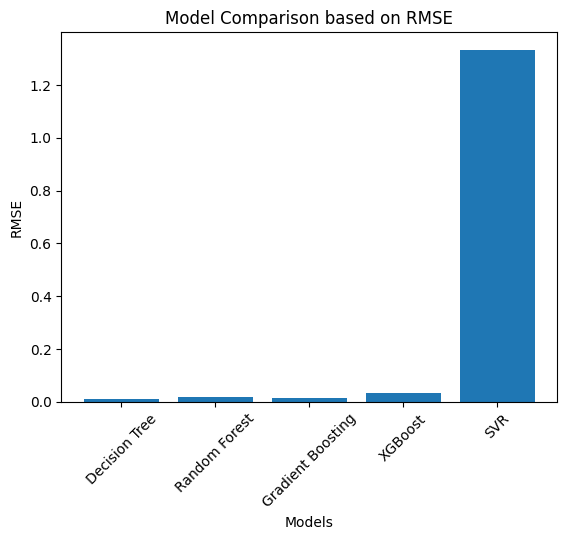

In [27]:
# Import matplotlib
import matplotlib.pyplot as plt

# Model names
models = ["Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost", "SVR"]

# RMSE values
rmse_values = [rmse, rf_rmse, gb_rmse, xgb_rmse, svr_rmse]

# Create bar chart
plt.bar(models, rmse_values)

# Axis labels
plt.xlabel("Models")
plt.ylabel("RMSE")

# Title
plt.title("Model Comparison based on RMSE")

# Rotate labels for clarity
plt.xticks(rotation=45)

# Show plot
plt.show()

## Model Comparison Visualization

The bar chart compares the RMSE values of different machine learning models. 
Models with lower RMSE have better prediction accuracy.

From the visualization, Decision Tree, Random Forest, and Gradient Boosting 
show very low RMSE values, indicating strong predictive performance. 
However, the SVR model shows a significantly higher RMSE, meaning it performs 
worse for this dataset.

This indicates that tree-based ensemble models are more suitable for predicting 
house prices in this dataset.